In [2]:
%pip install langchain-openai langgraph --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [1]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph

In [2]:
def print_workflow_info(workflow, app=None):
    """Prints comprehensive information about a LangGraph workflow."""
    print("WORKFLOW INFORMATION")
    print("====================")
    print(f"Nodes: {workflow.nodes}")
    print(f"Edges: {workflow.edges}")

    
    # Use getter method for finish points if available
    try:
        finish_points = workflow.finish_points
        print(f"Finish points: {finish_points}")
    except:
        try:
            # Alternative approaches
            print(f"Finish point: {workflow._finish_point}")
        except:
            print("Finish points attribute not directly accessible")
    
    if app:
        print("\nWorkflow Visualization:")
        from IPython.display import display
        display(app.get_graph().draw_png())

In [3]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

import os

llm = ChatOpenAI(
    api_key=os.environ["HUGGINGFACEHUB_API_TOKEN"],
    base_url="https://router.huggingface.co/v1",
    model="Qwen/Qwen3.5-397B-A17B:novita"
)

### Prompt Chaining

Prompt Chaining breaks complex tasks into sequential LLM steps, where each output feeds the next for progressive refinement. It uses modular steps via function calls, chains, or agents (for example in LangChain/LangGraph), often with tool calls between steps.

**Typical flow**
- Step 1: Generate an initial draft  
- Step 2: Refine tone/style/content  
- Step 3: Evaluate, format, or quality-check output  

**Common use cases**
- Content pipelines (idea → outline → draft → polish)  
- Report automation (extract → analyze → summarize)  
- Learning content generation (topic → questions → answers → explanations)

##### Use Case: Prompt Chaining — Job Application Assistant

In this workflow, we are going to build a simple **job application assistant** using the Prompt Chaining pattern. The goal is to help a user create a **personalized cover letter** from a given job description.

![Screenshot 2025-04-24 at 12.03.31 PM.png](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hseuyL5ddwU6cvKXrVGQnw/Screenshot%202025-04-24%20at%2012-03-31%E2%80%AFPM.png)

We will break the task into two sequential steps:
1. First, the LLM will read the **job description** and generate a **resume summary** tailored to that role.
2. Then, using this summary, the LLM will generate a professional **cover letter** suitable for submitting with a job application.


In [6]:
class ChainState(TypedDict):
    job_description: str
    resume_summary: str
    cover_letter: str

In [7]:
def generate_resume_summary(state: ChainState) -> ChainState:
    prompt = f"""
You're a resume assistant. Read the following job description and summarize the key qualifications and experience the ideal candidate should have, phrased as if from the perspective of a strong applicant's resume summary.

Job Description:
{state['job_description']}
"""

    response = llm.invoke(prompt)

    return {**state, "resume_summary": response.content}

In [8]:
def generate_cover_letter(state: ChainState) -> ChainState:
    prompt = f"""
You're a cover letter writing assistant. Using the resume summary below, write a professional and personalized cover letter for the following job.

Resume Summary:
{state['resume_summary']}

Job Description:
{state['job_description']}
"""

    response = llm.invoke(prompt)

    return {**state, "cover_letter": response.content}

In [9]:
workflow = StateGraph(ChainState)
workflow.add_node("generate_resume_summary", generate_resume_summary)
workflow.add_node("generate_cover_letter", generate_cover_letter)
workflow.set_entry_point("generate_resume_summary")
workflow.add_edge("generate_resume_summary", "generate_cover_letter")
workflow.set_finish_point("generate_cover_letter")
print_workflow_info(workflow)

WORKFLOW INFORMATION
Nodes: {'generate_resume_summary': StateNodeSpec(runnable=generate_resume_summary(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, ends=(), defer=False), 'generate_cover_letter': StateNodeSpec(runnable=generate_cover_letter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, ends=(), defer=False)}
Edges: {('generate_cover_letter', '__end__'), ('generate_resume_summary', 'generate_cover_letter'), ('__start__', 'generate_resume_summary')}
Finish points attribute not directly accessible


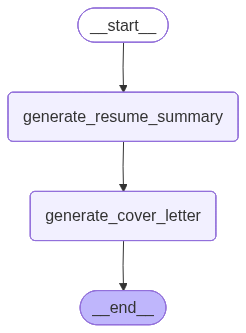

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generate_resume_summary(generate_resume_summary)
	generate_cover_letter(generate_cover_letter)
	__end__([<p>__end__</p>]):::last
	__start__ --> generate_resume_summary;
	generate_resume_summary --> generate_cover_letter;
	generate_cover_letter --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [10]:
from IPython.display import Image, display

app = workflow.compile()
display(Image(app.get_graph().draw_mermaid_png()))
print(app.get_graph().draw_mermaid())

In [12]:
input_state = {
        "job_description": "We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required."
}

result = app.invoke(input_state)
print(result['resume_summary'])

Accomplished Data Scientist with specialized expertise in Machine Learning, NLP, and Python. Demonstrated success in leveraging large-scale datasets to develop and deploy high-performance models into production environments.


In [13]:
result

{'job_description': 'We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required.',
 'resume_summary': 'Accomplished Data Scientist with specialized expertise in Machine Learning, NLP, and Python. Demonstrated success in leveraging large-scale datasets to develop and deploy high-performance models into production environments.',
 'cover_letter': "Subject: Application for Data Scientist Position\n\n[Your Name]\n[Your Address]\n[Your City, State, Zip Code]\n[Your Email]\n[Your Phone Number]\n[Date]\n\n[Hiring Manager's Name]\n[Company Name]\n[Company Address]\n[City, State, Zip Code]\n\nDear [Hiring Manager's Name],\n\nI am writing to express my enthusiastic interest in the Data Scientist position at [Company Name], as advertised. With a robust background in advanced analytics and model deployment, I am confident in my ability to contribute immediately to your team's g

### Workflow Pattern: Routing

Routing uses an LLM or router agent to classify input and direct it to the right specialized branch, useful when handling multiple intents or task types.

**Use cases**
- Customer support intent routing  
- Multi-skill agent dispatch (summarize/translate/extract)  
- Adaptive tutoring by subject  

**Techniques**
1. Keyword rules  
2. LLM classification prompts  
3. Embedding-based semantic routing

##### Use Case: Translation or Summarization Route Agent

In [14]:
class RouterState(TypedDict):
    user_input: str
    task_type: str
    output: str

In [15]:
class Router(BaseModel):
    role: str = Field(..., description="Decide whether the user wants to summarize a passage  ouput 'summarize'  or translate text into French oupput translate.")
llm_router=llm.bind_tools([Router])

In [17]:
response=llm_router.invoke("summarize this I love the sun its so warm")
response

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 128, 'prompt_tokens': 305, 'total_tokens': 433, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 96, 'rejected_prediction_tokens': 0, 'text_tokens': 128, 'image_tokens': 0, 'video_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'text_tokens': 305, 'image_tokens': 0, 'video_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3.5-397b-a17b', 'system_fingerprint': '', 'id': '760eeacfe35fb4a8b70a9724e22bfa6b', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cdb81-a6fd-78e1-9238-7193fe94e08c-0', tool_calls=[{'name': 'Router', 'args': {'role': 'summarize'}, 'id': 'call_485cb8f9729440a391bbc9f1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 305, 'output_tokens': 128, 'tota

In [18]:
def router_node(state: RouterState) -> RouterState:
    routing_prompt = f"""
    You are an AI task classifier.
    
    Decide whether the user wants to:
    - "summarize" a passage
    - or "translate" text into French
    
    Respond with just one word: 'summarize' or 'translate'.
    
    User Input: "{state['user_input']}"
    """

    response = llm_router.invoke(routing_prompt)

    return {**state, "task_type": response.tool_calls[0]['args']['role']} # This becomes the next node's name!

In [19]:
def router(state: RouterState) -> str:
    return state['task_type']

In [20]:
def summarize_node(state: RouterState) -> RouterState:
    prompt = f"Please summarize the following passage:\n\n{state['user_input']}"
    response = llm.invoke(prompt)
    
    return {**state, "task_type": "summarize", "output": response.content}

In [21]:
def translate_node(state: RouterState) -> RouterState:
    prompt = f"Translate the following text to French:\n\n{state['user_input']}"
    response = llm.invoke(prompt)

    return {**state, "task_type": "translate", "output": response.content}

In [22]:
workflow = StateGraph(RouterState)
workflow.add_node("router", router_node)
workflow.add_node("summarize", summarize_node)
workflow.add_node("translate", translate_node)
workflow.set_entry_point("router")
workflow.add_conditional_edges("router", router, {
    "summarize": "summarize",
    "translate": "translate"
})
workflow.set_finish_point("summarize")
workflow.set_finish_point("translate")
print_workflow_info(workflow)

WORKFLOW INFORMATION
Nodes: {'router': StateNodeSpec(runnable=router(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.RouterState'>, retry_policy=None, cache_policy=None, ends=(), defer=False), 'summarize': StateNodeSpec(runnable=summarize(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.RouterState'>, retry_policy=None, cache_policy=None, ends=(), defer=False), 'translate': StateNodeSpec(runnable=translate(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.RouterState'>, retry_policy=None, cache_policy=None, ends=(), defer=False)}
Edges: {('translate', '__end__'), ('__start__', 'router'), ('summarize', '__end__')}
Finish points attribute not directly accessible


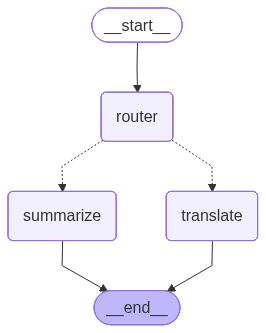

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	router(router)
	summarize(summarize)
	translate(translate)
	__end__([<p>__end__</p>]):::last
	__start__ --> router;
	router -.-> summarize;
	router -.-> translate;
	summarize --> __end__;
	translate --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [23]:
app = workflow.compile()
display(Image(app.get_graph().draw_mermaid_png()))
print(app.get_graph().draw_mermaid())

Translate task scenario,

In [24]:
input_text = {
        "user_input": "Can you translate this sentence: I love programming?"
    }

result = app.invoke(input_text)
print(result[ 'output'])
print(result['task_type'])


translate


Summarize task scenario,

In [26]:
input_text = {
        "user_input": "Can you summarize this sentence: I love programming so much it is the best thing ever. All I want to do is programming?"
    }

result = app.invoke(input_text)
print(result[ 'output'])
print(result['task_type'])

The speaker expresses an overwhelming passion for programming, viewing it as the best activity and their sole desire.
summarize


### Workflow Pattern: Parallelization

Parallelization runs independent LLM tasks simultaneously (instead of sequentially) to improve speed and throughput, then combines results.

**Use cases**
- Summarize large docs by section in parallel  
- Batch translation  
- Generate multiple content variants  
- Parallel safety checks  
- Multi-model/prompt ensembling  

**Techniques**
1. **Format diversity:** same input, different prompt styles/languages/formats in parallel.  
2. **Task splitting:** split large input into parts, process concurrently, then merge.  
3. **Consensus voting:** run multiple agents/prompts on the same task and pick best/majority result.

##### Use Case: Parallelization — Multilingual Translation Assistant

This workflow translates one English sentence into French, Spanish, and Japanese in parallel. Since each translation is independent, parallel execution is faster and more efficient, and the results are then combined into one multilingual output.

In [5]:
class State(TypedDict):
    text: str
    french: str
    spanish: str
    japanese: str
    combined_output: str

In [6]:
def translate_french(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to French:\n\n{state['text']}")
    return {"french": response.content.strip()}

In [7]:
def translate_spanish(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to Spanish:\n\n{state['text']}")
    return {"spanish": response.content.strip()}

In [8]:
def translate_japanese(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to Japanese:\n\n{state['text']}")
    return {"japanese": response.content.strip()}

In [9]:
def aggregator(state: State) -> dict:
    combined = f"Original Text: {state['text']}\n\n"
    combined += f"French: {state['french']}\n\n"
    combined += f"Spanish: {state['spanish']}\n\n"
    combined += f"Japanese: {state['japanese']}\n"
    return {"combined_output": combined}

In [10]:
graph = StateGraph(State)
graph.add_node("translate_french", translate_french)
graph.add_node("translate_spanish", translate_spanish)
graph.add_node("translate_japanese", translate_japanese)
graph.add_node("aggregator", aggregator)

# Connect parallel nodes from START
graph.add_edge(START, "translate_french")
graph.add_edge(START, "translate_spanish")
graph.add_edge(START, "translate_japanese")

# Connect all translation nodes to the aggregator
graph.add_edge("translate_french", "aggregator")
graph.add_edge("translate_spanish", "aggregator")
graph.add_edge("translate_japanese", "aggregator")

# Final node
graph.add_edge("aggregator", END)

print_workflow_info(graph)

WORKFLOW INFORMATION
Nodes: {'translate_french': StateNodeSpec(runnable=translate_french(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.State'>, retry_policy=None, cache_policy=None, ends=(), defer=False), 'translate_spanish': StateNodeSpec(runnable=translate_spanish(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.State'>, retry_policy=None, cache_policy=None, ends=(), defer=False), 'translate_japanese': StateNodeSpec(runnable=translate_japanese(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.State'>, retry_policy=None, cache_policy=None, ends=(), defer=False), 'aggregator': StateNodeSpec(runnable=aggregator(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.State'>, retry_policy=None, cache_policy=None, ends=(), defer=False)}
Edges: {('translate_spani

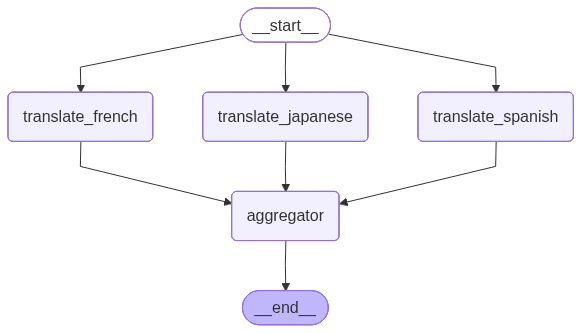

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	translate_french(translate_french)
	translate_spanish(translate_spanish)
	translate_japanese(translate_japanese)
	aggregator(aggregator)
	__end__([<p>__end__</p>]):::last
	__start__ --> translate_french;
	__start__ --> translate_japanese;
	__start__ --> translate_spanish;
	translate_french --> aggregator;
	translate_japanese --> aggregator;
	translate_spanish --> aggregator;
	aggregator --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [11]:
from IPython.display import Image, display

app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))
print(app.get_graph().draw_mermaid())

In [12]:
input_text = {
        "text": "Good morning! I hope you have a wonderful day."
}

result = app.invoke(input_text)
result

{'text': 'Good morning! I hope you have a wonderful day.',
 'french': "Bonjour ! J'espère que vous passerez une merveilleuse journée.",
 'spanish': '¡Buenos días! Espero que tengas un día maravilloso.',
 'japanese': 'おはようございます！素敵な一日になりますように。',
 'combined_output': "Original Text: Good morning! I hope you have a wonderful day.\n\nFrench: Bonjour ! J'espère que vous passerez une merveilleuse journée.\n\nSpanish: ¡Buenos días! Espero que tengas un día maravilloso.\n\nJapanese: おはようございます！素敵な一日になりますように。\n"}

### 📝 Exercise 1 - Create State Management and Router Tool
Define the state structure and classification tool for your multi-agent routing system. You need to create a TypedDict for state management and a Pydantic model for LLM tool binding.

Your task: Create the foundational components for routing between ride hailing, restaurant orders, groceries, and default handling.

In [13]:
# TODO: Define your RouterState TypedDict with three fields
# TODO: Create a Router BaseModel with proper field description
# TODO: Bind the router tool to your LLM
class RouterState(TypedDict):
    user_input: str
    task_type: str
    output: str

class Router(BaseModel):
    role: str = Field(
        ..., 
        description="Classify the user request. Return exactly one of: 'ride_hailing_call', 'restaurant_order', 'groceries' and if you do not know output 'default_handler'"
    )

llm_router = llm.bind_tools([Router])


### 📝 Exercise 2 - Implement Router Logic

Create the router node function that classifies user input and handles cases where the LLM doesn't return a tool call. Also implement the router decision function.

Your task: Build the classification logic with proper error handling for unclassified requests.


In [14]:
# TODO: Implement router_node function with tool call handling
# TODO: Add fallback to "default_handler" when no tool calls
# TODO: Create router function that returns task_type from state
def router_node(state: RouterState) -> RouterState:
    response = llm_router.invoke(state['user_input'])
    
    if response.tool_calls:
        tool_call = response.tool_calls[0]['args']['role']
        return {**state, "task_type": tool_call}
    else:
        return {**state, "task_type": "default_handler"}

def router(state: RouterState) -> str:
    return state['task_type']

In [15]:
def ride_hailing_node(state: RouterState) -> RouterState:
    """
    Processes ride hailing requests by extracting pickup/dropoff locations and preferences
    """
    prompt = f"""
    You are a ride hailing assistant. Based on the user's request, extract and organize the following information:
    
    - Pickup location
    - Destination/dropoff location  
    - Preferred ride type (if mentioned)
    - Any special requirements
    - Estimated timing preferences
    
    User Request: "{state['user_input']}"
    
    Provide a clear summary of the ride request with all available details.
    """
    
    response = llm.invoke(prompt)
    
    return {
        **state, 
        "task_type": "ride_hailing_call", 
        "output": response.content.strip()
    }

def restaurant_order_node(state: RouterState) -> RouterState:
    """
    Processes restaurant orders by organizing menu items, quantities, and preferences
    """
    prompt = f"""
    You are a restaurant ordering assistant. Based on the user's request, organize the following information:
    
    - Menu items requested
    - Quantities for each item
    - Special modifications or dietary restrictions
    - Delivery or pickup preference
    - Any timing requirements
    
    User Request: "{state['user_input']}"
    
    Provide a clear, organized summary of the restaurant order with all details.
    """
    
    response = llm.invoke(prompt)
    
    return {
        **state, 
        "task_type": "restaurant_order", 
        "output": response.content.strip()
    }

def groceries_node(state: RouterState) -> RouterState:
    """
    Processes grocery delivery requests with driver pickup service
    """
    prompt = f"""
    You are a grocery delivery assistant for a service where our drivers pick up groceries for customers.
    
    Based on the user's request, organize the following information:
    
    Shopping List:
    - List of grocery items needed
    - Quantities or amounts for each item
    - Brand preferences (if mentioned)
    - Any dietary restrictions or organic preferences
    
    Store Information:
    - Preferred store or location
    - Budget considerations
    - Special instructions for finding items
    
    Delivery Details:
    - Delivery address (if provided)
    - Preferred delivery time window
    - Any special delivery instructions
    - Contact information for driver coordination
    
    Driver Instructions:
    - Substitution preferences (if item unavailable)
    - How to handle out-of-stock items
    - Any items requiring special handling (fragile, cold items)
    - Payment method (if mentioned)
    
    User Request: "{state['user_input']}"
    
    Provide a comprehensive delivery order summary that our driver can use to efficiently shop and deliver groceries. 
    Include estimated pickup time and any special notes for the shopping trip.
    
    Format the response as a clear, organized delivery order that includes all necessary details for our driver service.
    """
    
    response = llm.invoke(prompt)
    
    return {
        **state, 
        "task_type": "groceries", 
        "output": response.content.strip()
    }
def default_handler_node(state: RouterState) -> RouterState:
    prompt = f"""
    I couldn't classify your request into a specific category. 
    Let me provide general assistance for: "{state['user_input']}"
    
    I can help you with:
    - Ride hailing services
    -  Restaurant orders  
    -  Grocery shopping
    
    Please rephrase your request to match one of these services, or if you need assistance with something else, I will connect you with our customer support team who can provide personalized help.
    
    Would you like me to:
    1. Help you rephrase your request for one of our services
    2. Connect you with customer support for additional assistance
    """
    response = llm.invoke(prompt)
    return {**state, "task_type": "default_handler", "output": response.content.strip()}


### 📝 Exercise 3 - Assemble the Complete Workflow

Put all the pieces together by building the StateGraph, adding nodes, setting up routing logic, and compiling the application.

Your task: Create the complete workflow graph with proper routing and finish points, and call it ```app```.


In [19]:
# TODO: Create StateGraph with RouterState
# TODO: Add all five nodes (router + 4 processing nodes)
# TODO: Set router as entry point
# TODO: Add conditional edges with all four routing options
# TODO: Set finish points for all processing nodes
# TODO: Compile the application
workflow = StateGraph(RouterState)
# Add all nodes
workflow.add_node("router", router_node)
workflow.add_node("ride_hailing_call", ride_hailing_node)
workflow.add_node("restaurant_order", restaurant_order_node)
workflow.add_node("groceries", groceries_node)
workflow.add_node("default_handler", default_handler_node)

# Set entry point
workflow.set_entry_point("router")

# Add conditional routing
workflow.add_conditional_edges("router", router, {
    "groceries": "groceries", 
    "restaurant_order": "restaurant_order",
    "ride_hailing_call": "ride_hailing_call",
    "default_handler": "default_handler"
})

# Set finish points
workflow.set_finish_point("ride_hailing_call")
workflow.set_finish_point("restaurant_order")
workflow.set_finish_point("groceries")
workflow.set_finish_point("default_handler")

# Compile the application
app = workflow.compile()

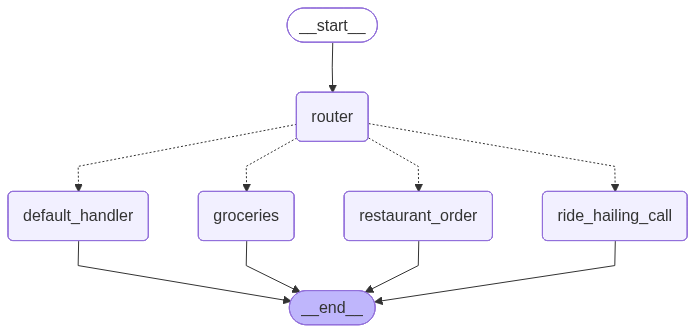

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	router(router)
	ride_hailing_call(ride_hailing_call)
	restaurant_order(restaurant_order)
	groceries(groceries)
	default_handler(default_handler)
	__end__([<p>__end__</p>]):::last
	__start__ --> router;
	router -.-> default_handler;
	router -.-> groceries;
	router -.-> restaurant_order;
	router -.-> ride_hailing_call;
	default_handler --> __end__;
	groceries --> __end__;
	restaurant_order --> __end__;
	ride_hailing_call --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [20]:
display(Image(app.get_graph().draw_mermaid_png()))
print(app.get_graph().draw_mermaid())

Test your implementation here:

In [21]:
test_cases = [
    {"user_input": "I need a ride from downtown to the airport at 3pm"},
    {"user_input": "I want to order 2 large pepperoni pizzas for delivery"},
    {"user_input": "I need milk, bread, eggs, and vegetables for the week"},
    {"user_input": "What's the weather like today?"},  # Default/unclassified example
]

for i, test_input in enumerate(test_cases, 1):
    result=app.invoke(test_input)


    print(f"question {test_input["user_input"]}\n")
    print(f"task_type {result['task_type']}\n")
    print(f"output: {result['output']}\n")
    print('-----------------------------------')

question I need a ride from downtown to the airport at 3pm

task_type ride_hailing_call

output: **Ride Request Summary**

*   **Pickup Location:** Downtown
*   **Destination/Dropoff Location:** Airport
*   **Preferred Ride Type:** Not specified
*   **Special Requirements:** None mentioned
*   **Estimated Timing Preferences:** 3:00 PM

-----------------------------------
question I want to order 2 large pepperoni pizzas for delivery

task_type restaurant_order

output: **Order Summary**

*   **Menu Items:** Large Pepperoni Pizza
*   **Quantity:** 2
*   **Special Modifications/Dietary Restrictions:** None
*   **Delivery/Pickup Preference:** Delivery
*   **Timing Requirements:** Not specified

-----------------------------------
question I need milk, bread, eggs, and vegetables for the week

task_type groceries

output: # 🛒 Grocery Delivery Order Summary

**Order ID:** #GD-2023-8842  
**Date:** October 26, 2023  
**Status:** Pending Customer Verification (Missing Details)  
**Estimated P